# Complete CA CNN Classification Pipeline

This notebook contains the complete pipeline for:
1. Data generation
2. Model training (5 models)
3. Evaluation and comparison

**Note**: This will take several hours to complete. Consider running data generation and model training separately using notebooks 1 and 2.

## 실행 방법

### Google Colab에서 실행
- 셀을 순서대로 실행 (환경 자동 감지)
- GPU 사용 권장

### 로컬 환경에서 실행
- 필요한 패키지 설치 후 실행
- 환경 자동 감지됨

## 🔧 Setup - Environment Detection

In [1]:
# 환경 감지 및 자동 설정
import sys
import os
from pathlib import Path

# Google Colab 환경 감지
try:
    import google.colab
    IN_COLAB = True
    print("🌐 Google Colab 환경 감지")
    
    # Google Drive 마운트
    print("\n💾 Google Drive 마운트 중...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    # 데이터 경로 설정
    BASE_PATH = Path('/content/drive/MyDrive/Research/CA')
    
except ImportError:
    IN_COLAB = False
    print("💻 로컬 환경 감지")
    
    # 로컬 경로 설정
    current_dir = Path.cwd()
    
    # 현재 디렉토리에서 CA 폴더 찾기
    if 'CA' in str(current_dir):
        while current_dir.name != 'CA' and current_dir.parent != current_dir:
            current_dir = current_dir.parent
        BASE_PATH = current_dir
    else:
        # 기본 경로 사용
        BASE_PATH = Path('/Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA')
        if not BASE_PATH.exists():
            BASE_PATH = current_dir

# 경로 설정
DATA_DIR = BASE_PATH / 'Data'
MODEL_DIR = DATA_DIR / 'models'
CHECKPOINT_DIR = DATA_DIR / 'checkpoints'
DATA_FILE = DATA_DIR / 'data500_50.pickle'

# 디렉토리 생성
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📂 작업 경로: {BASE_PATH}")
print(f"📂 데이터 경로: {DATA_DIR}")
print(f"💾 데이터 파일: {DATA_FILE}")
print(f"\n환경: {'Colab' if IN_COLAB else 'Local'}")

💻 로컬 환경 감지

📂 작업 경로: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA
📂 데이터 경로: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data
💾 데이터 파일: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/data500_50.pickle

환경: Local


## Import Libraries

In [2]:
import sys
import subprocess

# 필요한 패키지 자동 설치
def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# TensorFlow 설치 확인 및 설치
try:
    import tensorflow as tf
    print(f"✅ TensorFlow {tf.__version__} 로드 완료")
except ImportError:
    print("⚠️ TensorFlow를 찾을 수 없습니다. 설치를 시작합니다...")
    install_package("tensorflow")
    import tensorflow as tf
    print(f"✅ TensorFlow {tf.__version__} 설치 및 로드 완료")

# 나머지 라이브러리 import
import numpy as np
import numpy.random as rand
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split

print(f"GPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("✅ 라이브러리 로드 완료!")

✅ TensorFlow 2.20.0 로드 완료
GPU 사용 가능: False
✅ 라이브러리 로드 완료!


## 📊 Part 1: Data Generation

Generate training data by simulating Cellular Automata evolution.

In [3]:
# Set to True to generate new data, False to load existing
GENERATE_NEW_DATA = True  # 기존 데이터가 있으면 False로 설정

In [4]:
# Configuration - Method2 방식
# 128개 기본 규칙 (pad0)
CA_RULES = [i*2 for i in range(128)]

# CA_RULES = list(range(256))  # 0~255까지 모든 룰

# 제외할 규칙 (필요시 추가)
CA_0 = []  # 제외할 규칙이 있으면 여기에 추가

NUM_CLASSES = len(CA_RULES)
GRID_SIZE = 400
IMAGE_SIZE = 20
NUM_GENERATIONS = 20
NUM_SAMPLES_PER_RULE = 500
DENSITY_LEVELS = [1, 2, 3, 4, 5, 6]
CELLS_PER_DENSITY = 50

print(f"📊 설정 완료 (Method2)")
print(f"  - 총 CA 룰: {NUM_CLASSES}개")
print(f"  - 제외 규칙: {len(CA_0)}개")
print(f"  - 총 샘플: {(NUM_CLASSES - len(CA_0)) * NUM_SAMPLES_PER_RULE * len(DENSITY_LEVELS):,}개")

📊 설정 완료 (Method2)
  - 총 CA 룰: 128개
  - 제외 규칙: 0개
  - 총 샘플: 384,000개


In [5]:
# CA simulation functions - Method2 방식 (홀수/짝수 패딩 구분)

def get_wolfram_rule(rule_number):
    """
    Wolfram CA 규칙을 이진 매핑으로 변환
    """
    binary_rep = str(bin(rule_number))[2:]
    binary_rep = [0] * (8 - len(binary_rep)) + [int(b) for b in binary_rep]
    mapping = {
        (0,0,0): binary_rep[7], (0,0,1): binary_rep[6],
        (0,1,0): binary_rep[5], (0,1,1): binary_rep[4],
        (1,0,0): binary_rep[3], (1,0,1): binary_rep[2],
        (1,1,0): binary_rep[1], (1,1,1): binary_rep[0],
    }
    return mapping

def get_next_seq_pad0(previous_seq, rule_num):
    """
    짝수 규칙: 0으로 패딩
    """
    rule = get_wolfram_rule(rule_num)
    seq_length = len(previous_seq) - 2
    sub_seqs = [tuple(previous_seq[i:i + 3]) for i in range(seq_length)]
    new_seq = [rule[sub_seq] for sub_seq in sub_seqs]
    # 양 끝을 0으로 패딩
    new_seq.insert(0, 0)
    new_seq.append(0)
    return new_seq

def get_next_seq_pad1(previous_seq, rule_num):
    """
    홀수 규칙: 1로 패딩 (rule_num-1의 규칙 사용)
    """
    rule = get_wolfram_rule(rule_num - 1)
    seq_length = len(previous_seq) - 2
    sub_seqs = [tuple(previous_seq[i:i + 3]) for i in range(seq_length)]
    new_seq = [rule[sub_seq] for sub_seq in sub_seqs]
    # 양 끝을 1로 패딩
    new_seq.insert(0, 1)
    new_seq.append(1)
    return new_seq

def get_next_seq(previous_seq, rule_num):
    """
    규칙 번호에 따라 적절한 패딩 방식 선택
    짝수: pad0, 홀수: pad1
    """
    if rule_num % 2 == 0:
        return get_next_seq_pad0(previous_seq, rule_num)
    else:
        return get_next_seq_pad1(previous_seq, rule_num)

def rule_data20(start, rule_num):
    """
    정확히 20세대 진화
    """
    prev = start
    for _ in range(20):
        prev = get_next_seq(prev, rule_num)
    return prev

def generate_single_sample(rule_number, density_level, seed=None):
    """
    단일 샘플 생성 (Method2 방식)
    """
    if seed is not None:
        rand.seed(seed)
    
    # One-hot 인코딩
    y = np.zeros(NUM_CLASSES)
    y[CA_RULES.index(rule_number)] = 1
    
    # 초기 상태 생성
    num_active_cells = CELLS_PER_DENSITY * density_level
    idx = rand.choice(GRID_SIZE, num_active_cells, replace=False)
    initial_state = np.zeros(GRID_SIZE)
    initial_state[idx] = 1
    
    # 4개 시간대 진화
    gen_2030_seq = np.array(initial_state)
    gen_2050_seq = np.array(rule_data20(gen_2030_seq, rule_number))
    gen_2070_seq = np.array(rule_data20(gen_2050_seq, rule_number))
    gen_2090_seq = np.array(rule_data20(gen_2070_seq, rule_number))
    
    # 20x20 행렬로 변환
    gen_2030_mat = gen_2030_seq.reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2050_mat = gen_2050_seq.reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2070_mat = gen_2070_seq.reshape(IMAGE_SIZE, IMAGE_SIZE)
    gen_2090_mat = gen_2090_seq.reshape(IMAGE_SIZE, IMAGE_SIZE)
    
    # (4, 20, 20) 형태로 스택
    X = np.array([gen_2030_mat, gen_2050_mat, gen_2070_mat, gen_2090_mat])
    return X, y

print("✅ CA 시뮬레이션 함수 정의 완료! (Method2 - 홀수/짝수 패딩 구분)")

✅ CA 시뮬레이션 함수 정의 완료! (Method2 - 홀수/짝수 패딩 구분)


In [6]:
if GENERATE_NEW_DATA:
    print("🔄 데이터 생성 시작... (Method2)")
    print("⏱️ 예상 시간: 약 30-40분\n")
    
    X_list = []
    y_list = []
    
    for rule in tqdm(CA_RULES, desc="Processing rules"):
        # CA_0에 포함된 규칙은 건너뛰기
        if rule in CA_0:
            continue
            
        for sample_idx in range(NUM_SAMPLES_PER_RULE):
            for density_level in DENSITY_LEVELS:
                seed = 500 * rule + sample_idx
                X_i, y_i = generate_single_sample(rule, density_level, seed=seed)
                X_list.append(X_i)
                y_list.append(y_i)
    
    X = np.array(X_list)
    y = np.array(y_list)
    X = np.transpose(X, (0, 2, 3, 1))
    
    print(f"\n✅ 데이터 생성 완료!")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
    
    # Save data
    print(f"\n💾 데이터 저장 중: {DATA_FILE}")
    with open(DATA_FILE, 'wb') as f:
        pickle.dump((X, y), f, pickle.HIGHEST_PROTOCOL)
    print(f"✅ 데이터 저장 완료!")
else:
    print(f"📂 기존 데이터 로드: {DATA_FILE}")
    with open(DATA_FILE, 'rb') as f:
        X, y = pickle.load(f)
    print(f"✅ 데이터 로드 완료! X: {X.shape}, y: {y.shape}")

🔄 데이터 생성 시작... (Method2)
⏱️ 예상 시간: 약 30-40분



Processing rules: 100%|██████████| 128/128 [16:01<00:00,  7.51s/it]



✅ 데이터 생성 완료!
  X shape: (384000, 20, 20, 4)
  y shape: (384000, 128)

💾 데이터 저장 중: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/data500_50.pickle
✅ 데이터 저장 완료!


## 🧠 Part 2: Model Training

Train 5 independent CNN models.

In [7]:
# Training Configuration
INPUT_SHAPE = (20, 20, 4)
BATCH_SIZE = 100
EPOCHS = 100
NUM_MODELS = 5
MODEL_SEEDS = [42, 123, 456, 789, 1011]

print(f"🎯 학습 설정")
print(f"  - 모델 개수: {NUM_MODELS}")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")

🎯 학습 설정
  - 모델 개수: 5
  - Epochs: 100
  - Batch size: 100


In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
print(f"📊 데이터 분할")
print(f"  - Training: {len(X_train):,}")
print(f"  - Test: {len(X_test):,}")

📊 데이터 분할
  - Training: 307,200
  - Test: 76,800


In [9]:
# Model building functions
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_cnn_model():
    model = models.Sequential([
        layers.InputLayer(input_shape=INPUT_SHAPE),
        layers.Conv2D(32, (3, 3), activation="relu", padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

print("✅ 모델 빌드 함수 정의 완료!")

✅ 모델 빌드 함수 정의 완료!


In [10]:
# Train all models
results = {}

print("🚀 모델 학습 시작...")
print(f"⏱️ 예상 시간: 약 2-3시간 (GPU 사용 시)\n")

for i in range(NUM_MODELS):
    model_idx = i + 1
    seed = MODEL_SEEDS[i]
    
    print(f"\n{'='*70}")
    print(f"🔵 Model {model_idx} / {NUM_MODELS} (seed={seed})")
    print(f"{'='*70}")
    
    set_seed(seed)
    model = build_cnn_model()
    
    checkpoint_path = str(CHECKPOINT_DIR / f"model_checkpoint_{model_idx}.weights.h5")
    callbacks = [
        ModelCheckpoint(checkpoint_path, save_weights_only=True, monitor='val_loss', 
                       mode='min', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1),
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
    ]
    
    history = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2
    )
    
    score = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n📊 Test Accuracy: {score[1]:.4f}")
    print(f"📊 Test Loss: {score[0]:.4f}")
    
    model_path = str(MODEL_DIR / f"model_{model_idx}.keras")
    model.save(model_path)
    print(f"💾 Model saved: {model_path}")
    
    results[f"model_{model_idx}"] = {
        "test_accuracy": score[1],
        "test_loss": score[0],
        "seed": seed,
        "epochs_trained": len(history.history['loss'])
    }

print("\n" + "="*70)
print("🎉 모든 모델 학습 완료!")
print("="*70)

🚀 모델 학습 시작...
⏱️ 예상 시간: 약 2-3시간 (GPU 사용 시)


🔵 Model 1 / 5 (seed=42)


/Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/sdm_env/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/100

Epoch 1: val_loss improved from None to 0.69544, saving model to /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/checkpoints/model_checkpoint_1.weights.h5
2765/2765 - 57s - 21ms/step - accuracy: 0.5929 - loss: 1.1671 - val_accuracy: 0.7152 - val_loss: 0.6954 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 0.69544 to 0.58745, saving model to /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/checkpoints/model_checkpoint_1.weights.h5
2765/2765 - 64s - 23ms/step - accuracy: 0.7272 - loss: 0.6750 - val_accuracy: 0.7528 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_loss improved from 0.58745 to 0.53196, saving model to /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/checkpoints/model_checkpoint_1.weights.h5
2765/2765 - 64s - 23ms/step - accuracy: 0.7547 - loss: 0.5973 - val_accuracy: 0.7731 - val_loss: 0.532

## 📈 Part 3: Results Summary

In [11]:
print("\n📊 학습 결과 요약")
print("="*70)
for model_name, result in results.items():
    print(f"{model_name}:")
    print(f"  - Accuracy: {result['test_accuracy']:.4f}")
    print(f"  - Loss: {result['test_loss']:.4f}")
    print(f"  - Epochs: {result['epochs_trained']}")
    print(f"  - Seed: {result['seed']}")
    print()

avg_accuracy = np.mean([r['test_accuracy'] for r in results.values()])
avg_loss = np.mean([r['test_loss'] for r in results.values()])

print(f"평균 Test Accuracy: {avg_accuracy:.4f}")
print(f"평균 Test Loss: {avg_loss:.4f}")


📊 학습 결과 요약
model_1:
  - Accuracy: 0.8277
  - Loss: 0.4239
  - Epochs: 29
  - Seed: 42

model_2:
  - Accuracy: 0.8266
  - Loss: 0.4239
  - Epochs: 28
  - Seed: 123

model_3:
  - Accuracy: 0.8255
  - Loss: 0.4297
  - Epochs: 29
  - Seed: 456

model_4:
  - Accuracy: 0.8290
  - Loss: 0.4234
  - Epochs: 27
  - Seed: 789

model_5:
  - Accuracy: 0.8278
  - Loss: 0.4174
  - Epochs: 22
  - Seed: 1011

평균 Test Accuracy: 0.8273
평균 Test Loss: 0.4237


💾 비교 그래프 저장: /Users/mkim/Library/CloudStorage/GoogleDrive-wuj2293@gmail.com/내 드라이브/Research/CA/Data/models/model_comparison.png


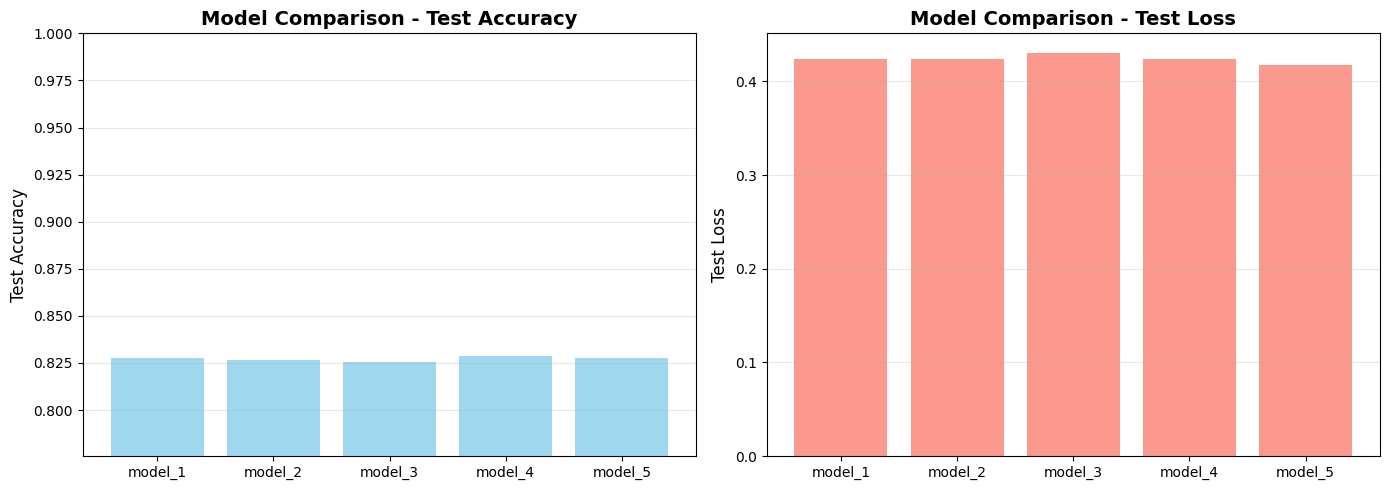


✅ 전체 파이프라인 완료!


In [12]:
# Visualization
model_names = list(results.keys())
accuracies = [results[m]['test_accuracy'] for m in model_names]
losses = [results[m]['test_loss'] for m in model_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(model_names, accuracies, color='skyblue', alpha=0.8)
ax1.set_ylabel('Test Accuracy', fontsize=12)
ax1.set_title('Model Comparison - Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([min(accuracies) - 0.05, 1.0])
ax1.grid(True, alpha=0.3, axis='y')

# Loss comparison
ax2.bar(model_names, losses, color='salmon', alpha=0.8)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Model Comparison - Test Loss', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
comparison_path = str(MODEL_DIR / 'model_comparison.png')
plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
print(f"💾 비교 그래프 저장: {comparison_path}")
plt.show()

print("\n✅ 전체 파이프라인 완료!")